# Codificación de elementos textuales

## Importación de librerias necesarias

In [1]:
import os
os.getenv('LD_LIBRARY_PATH')

'/usr/lib/x86_64-linux-gnu'

In [2]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

2025-11-17 13:58:18.109805: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [4]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")

JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [5]:
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

In [6]:
import pandas as pd
import tensorflow_hub as hub
from pyspark.ml.functions import array_to_vector

In [7]:
from src.utils.spark import SparkUtils

In [8]:
spark_utils = SparkUtils('encoding', True)
spark = spark_utils.spark

2025-11-17 13:58:33,392 - SparkCreator - INFO - Starts creating environment
25/11/17 13:58:35 WARN Utils: Your hostname, edgar-MS-7C96 resolves to a loopback address: 127.0.1.1; using 192.168.1.33 instead (on interface enp34s0)
25/11/17 13:58:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-conda-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-a26479cd-ab2f-4c6d-9103-b7532c859769;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 138ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

In [9]:
REGENERATE_INTERMEDIATE_TABLES = False

In [10]:
from pyspark.sql import functions as F, types as T
from pyspark.sql.window import Window

In [11]:
GOLD_SCHEMA = 'gold.premodeling'
GOLD_SCHEMA_ENCODING = 'gold.encoding'
SCHEMA = 'silver.preprocess'

In [12]:
MODULE_URL = "https://tfhub.dev/google/universal-sentence-encoder-large/5"
model = hub.load( MODULE_URL )

2025-11-17 13:58:41,453 - absl - INFO - Using /mnt/d/Maestría/Amazon Reviews Code/tf_cache to cache modules.
I0000 00:00:1763405922.328464  404118 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1763405922.328685  404118 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3884 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:10:00.0, compute capability: 8.6
2025-11-17 13:58:50,809 - absl - INFO - Fingerprint not found. Saved model loading will continue.
2025-11-17 13:58:50,810 - absl - INFO - path_and_singleprint metric could not be logged. Saved model loading will continue.


In [13]:
spark.conf.set("spark.sql.shuffle.partitions", "16")
spark.conf.set("spark.local.dir", "/mnt/d/tmp_spark")

In [14]:
os.getenv('SPARK_LOCAL_DIRS')

'/mnt/d/tmp_spark'

## Importar información transformada

In [15]:
main_category_encoded = spark.read.format('delta').load(spark_utils.path(
    'main_category_encoded', catalog = GOLD_SCHEMA
))

In [16]:
meta_items_title_text_clean = spark.read.format('delta').load(spark_utils.path(
    'meta_items_title_text_clean', catalog = GOLD_SCHEMA
))

In [17]:
meta_items_description_sentences_text_clean = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_sentences_text_clean', catalog = GOLD_SCHEMA
))

In [18]:
meta_items_features_text_clean = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_text_clean', catalog = GOLD_SCHEMA
))

In [19]:
reviews_indexed_sentences = spark.read.format('delta').load(spark_utils.path(
    'reviews_indexed_sentences', catalog = GOLD_SCHEMA
))

In [20]:
reviews_indexed = spark.read.format('delta').load(spark_utils.path(
    'reviews_indexed', catalog = SCHEMA
))

In [21]:
df_items_sample_balanced = spark.read.format('delta').load(spark_utils.path(
    'df_items_sample_balanced', catalog = GOLD_SCHEMA
))

In [22]:
reviews_indexed_sentences_items_sample_balanced = spark.read.format('delta').load(spark_utils.path(
    'reviews_indexed_sentences_items_sample_balanced', catalog = GOLD_SCHEMA
))

## Codificar textos generados en proceso de limpieza de datos

### Definir función genérica para codificación

In [23]:
from src.utils.models.encoding.SentenceMiniEncoder import SentenceMiniEncoder
from src.utils.models.encoding.SentenceEncoder import SentenceEncoder
encoder = SentenceEncoder(spark_utils)
mini_encoder = SentenceMiniEncoder(spark_utils)

/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl5mutex6unlockEv']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/tensorflow_io/python/ops/libtensorflow_io.s

### Codficación componente de títulos

In [25]:
if REGENERATE_INTERMEDIATE_TABLES:
    encoder.process_to_parquet(
        meta_items_title_text_clean,
        col="title",
        id_col="parent_asin",
        batch_size=5000,
        tf_batch=128,
        parquet_path=spark_utils.path(
        'meta_items_title_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ),
    overwrite_parquet=False
)

In [26]:
meta_items_title_text_clean_embeddings = (
    spark.read.format('parquet').load(spark_utils.path(
        'meta_items_title_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

In [27]:
meta_items_title_text_clean_embeddings.filter(F.col('parent_asin') == 'B000NNS5XS').toPandas().values

array([['B000NNS5XS',
        list([-0.006168861873447895, 0.05838214233517647, -0.003244376042857766, 0.016247548162937164, 0.048902690410614014, -0.0006903752801008523, -0.024342214688658714, 0.08234379440546036, 0.0507374070584774, -0.014095411635935307, 0.05119865760207176, -0.0557737834751606, -0.03441857919096947, 0.04510165750980377, 0.048485785722732544, -0.038509804755449295, -0.02678433060646057, 0.02384502813220024, -0.028811123222112656, -0.03452134504914284, -0.08000448346138, -0.023973917588591576, -0.05102322995662689, 0.10421822965145111, 0.08329559862613678, -0.007888817228376865, 0.03606826066970825, 0.022677471861243248, 0.001183191780000925, -0.073262058198452, 0.060947220772504807, -0.013767927885055542, 0.004226012621074915, 0.06508404016494751, 0.04774320870637894, -0.08587195724248886, 0.0075133852660655975, -0.08370854705572128, 0.014569480903446674, 0.0655180960893631, 0.012542756274342537, 0.08234749734401703, -0.0017918474040925503, -0.07462280988693237, -0.

### Codficación componente de descripciones

In [28]:
if REGENERATE_INTERMEDIATE_TABLES:
    encoder.process_to_parquet(
        meta_items_description_sentences_text_clean,
        col="description_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
        'meta_items_description_sentences_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ),
    overwrite_parquet=False
)

In [29]:
meta_items_description_sentences_text_clean_embeddings = (
    spark.read.format('parquet').load(spark_utils.path(
        'meta_items_description_sentences_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

In [30]:
meta_items_description_sentences_text_clean.filter(F.col('parent_asin') == 'B000NNS5XS')

DataFrame[parent_asin: string, description_sentence: string, paragraph_number: int, sentence_number: int, record_id: int]

### Codficación componente de características

In [31]:
if REGENERATE_INTERMEDIATE_TABLES:
    encoder.process_to_parquet(
        meta_items_features_text_clean,
        col="feature_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
        'meta_items_features_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ),
    overwrite_parquet=False
)

In [32]:
meta_items_features_text_clean_embeddings = (
    spark.read.format('parquet').load(spark_utils.path(
        'meta_items_features_text_clean_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

### Codficación oraciones de reseñas

In [33]:
reviews_indexed_sentences.show(1)

25/11/11 21:04:55 ERROR NonFateSharingFuture: Failed to get result from future
scala.runtime.NonLocalReturnControl


+---------+--------------------+---------------+------------+
|review_id|       text_sentence|sentence_number|   record_id|
+---------+--------------------+---------------+------------+
| 15852836|After wrestling t...|              4|274878342586|
+---------+--------------------+---------------+------------+
only showing top 1 row



In [34]:
if REGENERATE_INTERMEDIATE_TABLES:
    encoder.process_to_parquet(
        reviews_indexed_sentences,
        col="text_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
            'reviews_indexed_sentences_embeddings', 
            catalog = GOLD_SCHEMA_ENCODING
        ),
        overwrite_parquet=True
    )

In [35]:
reviews_indexed_sentences_embeddings = (
    spark.read.format('parquet').load(spark_utils.path(
        'reviews_indexed_sentences_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

In [36]:
if REGENERATE_INTERMEDIATE_TABLES:
    encoder.process_to_parquet(
        reviews_indexed_sentences_items_sample_balanced,
        col="text_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
            'reviews_indexed_sentences_items_sample_balanced_embeddings', 
            catalog = GOLD_SCHEMA_ENCODING
        ),
        overwrite_parquet=False
    )

In [23]:
reviews_indexed_sentences_items_sample_balanced_embeddings = (
    spark.read.format('parquet').load(spark_utils.path(
        'reviews_indexed_sentences_items_sample_balanced_embeddings', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

In [38]:
reviews_indexed_sentences_items_sample_balanced_embeddings_repartitioned = (
    reviews_indexed_sentences_items_sample_balanced_embeddings.alias('A')
        .join(
            reviews_indexed_sentences_items_sample_balanced.alias('B'),
            on = 'record_id',
            how = 'inner'
        )
        .select('A.*', 'B.review_id')
        .repartition('review_id')
)

In [40]:
# if True:
#     (
#         reviews_indexed_sentences_items_sample_balanced_embeddings_repartitioned
#             .write
#             .format('delta')
#             .mode('overwrite')
#             .save(spark_utils.path(
#                 'reviews_indexed_sentences_items_sample_balanced_embeddings_repartitioned', 
#                 catalog = GOLD_SCHEMA_ENCODING
#             ))
#     )

# reviews_indexed_sentences_items_sample_balanced_embeddings_repartitioned = spark.read.format('delta').load(spark_utils.path(
#     'reviews_indexed_sentences_items_sample_balanced_embeddings_repartitioned', 
#     catalog = GOLD_SCHEMA_ENCODING
# ))

### Codficación componente de títulos (miniLM)

In [41]:
if REGENERATE_INTERMEDIATE_TABLES:
    mini_encoder.process_to_parquet(
        meta_items_title_text_clean,
        col="title",
        id_col="parent_asin",
        batch_size=5000,
        tf_batch=128,
        parquet_path=spark_utils.path(
            'meta_items_title_text_clean_embeddings_minillm', 
            catalog = GOLD_SCHEMA_ENCODING,
        ),
        overwrite_parquet=False
    )

In [42]:
meta_items_title_text_clean_embeddings_minillm = (
    spark.read.format('parquet').load(spark_utils.path(
        'meta_items_title_text_clean_embeddings_minillm', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

### Codficación componente de descripciones (miniLM)

In [43]:
if REGENERATE_INTERMEDIATE_TABLES:
    mini_encoder.process_to_parquet(
        meta_items_description_sentences_text_clean,
        col="description_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
        'meta_items_description_sentences_text_clean_embeddings_minillm', 
        catalog = GOLD_SCHEMA_ENCODING
    ),
    overwrite_parquet=False
)

In [44]:
meta_items_description_sentences_text_clean_embeddings_minillm = (
    spark.read.format('parquet').load(spark_utils.path(
        'meta_items_description_sentences_text_clean_embeddings_minillm', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

### Codficación componente de características (miniLM)

In [45]:
if REGENERATE_INTERMEDIATE_TABLES:
    mini_encoder.process_to_parquet(
        meta_items_features_text_clean,
        col="feature_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
        'meta_items_features_text_clean_embeddings_minillm', 
        catalog = GOLD_SCHEMA_ENCODING
    ),
    overwrite_parquet=True
)

In [46]:
meta_items_features_text_clean_embeddings_minillm = (
    spark.read.format('parquet').load(spark_utils.path(
        'meta_items_features_text_clean_embeddings_minillm', 
        catalog = GOLD_SCHEMA_ENCODING
    ))
)

### Codficación oraciones de reseñas (miniLM)

In [47]:
if REGENERATE_INTERMEDIATE_TABLES:
    mini_encoder.process_to_parquet(
        reviews_indexed_sentences,
        col="text_sentence",
        id_col="record_id",
        batch_size=5000,
        tf_batch=32,
        parquet_path=spark_utils.path(
            'reviews_indexed_sentences_embeddings_minillm', 
            catalog = GOLD_SCHEMA_ENCODING
        ),
        overwrite_parquet=True
    )

In [48]:
# reviews_indexed_sentences_embeddings_minillm = (
#     spark.read.format('parquet').load(spark_utils.path(
#         'reviews_indexed_sentences_embeddings_minillm', 
#         catalog = GOLD_SCHEMA_ENCODING
#     ))
# )

## Recopilación de frases individuales

In [49]:
meta_items_encodings = (
    meta_items_title_text_clean_embeddings
        .withColumn('component', F.lit('title'))
        .union(
            meta_items_description_sentences_text_clean_embeddings
                .withColumn('component', F.lit('description'))
        )
        .union(
            meta_items_features_text_clean_embeddings
                .withColumn('component', F.lit('features'))
        )
)

In [50]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_encodings.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_encodings', catalog=GOLD_SCHEMA_ENCODING))
    )
meta_items_encodings = spark.read.format('delta').load(spark_utils.path(
    'meta_items_encodings', catalog = GOLD_SCHEMA_ENCODING
))

## Recopilación de frases individuales (miniLM)

In [51]:
meta_items_encodings_minillm = (
    meta_items_title_text_clean_embeddings_minillm
        .withColumn('component', F.lit('title'))
        .union(
            meta_items_description_sentences_text_clean_embeddings_minillm
                .withColumn('component', F.lit('description'))
        )
        .union(
            meta_items_features_text_clean_embeddings_minillm
                .withColumn('component', F.lit('features'))
        )
)

In [52]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_encodings_minillm.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_encodings_minillm', catalog=GOLD_SCHEMA_ENCODING))
    )
meta_items_encodings_minillm = spark.read.format('delta').load(spark_utils.path(
    'meta_items_encodings_minillm', catalog = GOLD_SCHEMA_ENCODING
))

## Recursos generales ponderación

In [24]:
import numpy as np

In [25]:
schema = T.StructType([
    T.StructField("parent_asin", T.StringType()),
    T.StructField("text_embeddings", T.ArrayType(T.DoubleType()))
])

schema_review = T.StructType([
    T.StructField("review_id", T.StringType()),
    T.StructField("text_embeddings", T.ArrayType(T.DoubleType()))
])

@F.pandas_udf(schema, functionType=F.PandasUDFType.GROUPED_MAP)
def sum_weighted_embeddings(pdf):
    weighted_embeds = np.stack(pdf['weighted_embedding'].values)
    
    summed = weighted_embeds.sum(axis=0)
    
    return pd.DataFrame({
        'parent_asin': [pdf['parent_asin'].iloc[0]],
        'text_embeddings': [summed.tolist()]
    })
    
@F.pandas_udf(schema_review, functionType=F.PandasUDFType.GROUPED_MAP)
def avg_weighted_embeddings(pdf):
    weighted_embeds = np.stack(pdf['weighted_embedding'].values)
    
    summed = weighted_embeds.mean(axis=0)
    
    return pd.DataFrame({
        'review_id': [pdf['review_id'].iloc[0]],
        'text_embeddings': [summed.tolist()]
    })

from pyspark.ml.stat import Summarizer
mean_summarizer = Summarizer.metrics("mean")

## Promediar embeddings por producto

### Aproximación mediante TFIDF

In [55]:
from src.gold.encoding.tfidf import TfidfEncoder

In [56]:
words_totals = meta_items_title_text_clean.select(F.col("title").alias('text')).union(
    meta_items_description_sentences_text_clean.select(F.col("description_sentence").alias('text'))
).union(
    meta_items_features_text_clean.select(F.col("feature_sentence").alias('text'))
)

In [57]:
TFIDF_PATH = spark_utils.path('tfidf_encoder', catalog = GOLD_SCHEMA_ENCODING)

In [58]:
tf_idf_encoder = TfidfEncoder(
    should_tokenize = True,
    input_col = "text",
    output_col = "text_sentence_tfidf"
)

In [59]:
if REGENERATE_INTERMEDIATE_TABLES:
    tf_idf_encoder.fit(words_totals)
    tf_idf_encoder.save(TFIDF_PATH)

tf_idf_encoder = TfidfEncoder(
    should_tokenize = True,
    input_col = "text",
    output_col = "text_sentence_tfidf"
)

tf_idf_encoder.load(TFIDF_PATH)

In [60]:
@F.udf(returnType=T.DoubleType())
def avg_tfidf(vec):
    return float(vec.values.mean()) if vec.numNonzeros() > 0 else 0.0

In [61]:
meta_items_title_text_clean_tfidf = tf_idf_encoder.transform(
    meta_items_title_text_clean.select(
        F.col("parent_asin"),
        F.col("title").alias('text')
    )
).withColumn("avg_tfidf", avg_tfidf(F.col("text_sentence_tfidf"))).select(
    "parent_asin",
    "avg_tfidf"
)

meta_items_description_sentences_text_clean_tfidf = tf_idf_encoder.transform(
    meta_items_description_sentences_text_clean.select(
        F.col("parent_asin"),
        F.col("record_id"),
        F.col("description_sentence").alias('text')
    )
).withColumn(
    "avg_tfidf", avg_tfidf(F.col("text_sentence_tfidf"))
).select(
    "parent_asin",
    "record_id",
    "avg_tfidf"
)

meta_items_features_text_clean_tfidf = tf_idf_encoder.transform(
    meta_items_features_text_clean.select(
        F.col("parent_asin"),
        F.col("record_id"),
        F.col("feature_sentence").alias('text')
    )
).withColumn(
    "avg_tfidf", avg_tfidf(F.col("text_sentence_tfidf"))
).select(
    "parent_asin",
    "record_id",
    "avg_tfidf"
)

In [62]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_title_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_title_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )
    (
        meta_items_description_sentences_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_description_sentences_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )
    (
        meta_items_features_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_features_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )

meta_items_title_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_title_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_description_sentences_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_sentences_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_features_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))

In [63]:
window = Window.partitionBy("parent_asin")

meta_items_description_sentences_text_clean_tfidf = meta_items_description_sentences_text_clean_tfidf.withColumn(
    "total_tfidf", F.sum("avg_tfidf").over(window)
).withColumn(
    "tfidf_ratio", F.col("avg_tfidf") / F.col("total_tfidf")
)

meta_items_features_text_clean_tfidf = meta_items_features_text_clean_tfidf.withColumn(
    "total_tfidf", F.sum("avg_tfidf").over(window)
).withColumn(
    "tfidf_ratio", F.col("avg_tfidf") / F.col("total_tfidf")
)

In [64]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_description_sentences_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_description_sentences_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )
    (
        meta_items_features_text_clean_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_features_text_clean_tfidf', catalog=GOLD_SCHEMA_ENCODING))
    )
meta_items_description_sentences_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_sentences_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_features_text_clean_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_text_clean_tfidf', catalog = GOLD_SCHEMA_ENCODING
))

### Ejecución de ponderación

In [65]:
from src.utils.constants import TITLE_WEIGHT, DESCRIPTION_WEIGHT, FEATURES_WEIGHT

#### Sumarización basada en TFIDF

In [66]:
meta_items_title_embeddings_tfidf = (
    meta_items_title_text_clean_embeddings.select(
        'parent_asin',
        F.transform(
            F.col("text_embeddings"),
            lambda x: x * F.lit(TITLE_WEIGHT)
        ).alias('text_embeddings'),
    )
)

In [67]:
meta_items_description_embeddings_tfidf = (
    meta_items_description_sentences_text_clean_embeddings.alias('A')
        .join(
            meta_items_description_sentences_text_clean_tfidf.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "embedding_array",
            F.col("text_embeddings")
        )
        .withColumn(
            "weighted_embedding",
            F.transform(F.col("embedding_array"), 
            lambda x: x * F.col("tfidf_ratio") * F.lit(DESCRIPTION_WEIGHT))
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/pyspark/sql/pandas/group_ops.py:104: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(


In [68]:
meta_items_features_embeddings_tfidf = (
    meta_items_features_text_clean_embeddings.alias('A')
        .join(
            meta_items_features_text_clean_tfidf.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "embedding_array",
            F.col("text_embeddings")
        )
        .withColumn(
            "weighted_embedding",
            F.transform(F.col("embedding_array"), 
            lambda x: x * F.col("tfidf_ratio") * F.lit(FEATURES_WEIGHT))
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

In [69]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_title_embeddings_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_title_embeddings_tfidf', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    (
        meta_items_description_embeddings_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_description_embeddings_tfidf', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    (
        meta_items_features_embeddings_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_features_embeddings_tfidf', catalog=GOLD_SCHEMA_ENCODING
            ))
    )

meta_items_title_embeddings_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_title_embeddings_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_description_embeddings_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_embeddings_tfidf', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_features_embeddings_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_embeddings_tfidf', catalog = GOLD_SCHEMA_ENCODING
))


In [70]:
zero_vector = F.array([F.lit(0.0)] * 512)

In [71]:
meta_items_embeddings_tfidf = (
    main_category_encoded.alias('A')
        .join(
            meta_items_title_embeddings_tfidf.alias('B'),
            on='parent_asin',
            how='left'
        )
        .join(
            meta_items_description_embeddings_tfidf.alias('C'),
            on='parent_asin',
            how='left'
        )
        .join(
            meta_items_features_embeddings_tfidf.alias('D'),
            on='parent_asin',
            how='left'
        )
        .withColumn(
            "title_embed",
            F.when(F.col("B.text_embeddings").isNotNull(), F.col("B.text_embeddings")).otherwise(zero_vector)
        )
        .withColumn(
            "desc_embed",
            F.when(F.col("C.text_embeddings").isNotNull(), F.col("C.text_embeddings")).otherwise(zero_vector)
        )
        .withColumn(
            "feat_embed",
            F.when(F.col("D.text_embeddings").isNotNull(), F.col("D.text_embeddings")).otherwise(zero_vector)
        )
        .withColumn(
            "sum_embedding",
            F.zip_with(
                F.zip_with(F.col("title_embed"), F.col("desc_embed"), lambda x, y: x + y),
                F.col("feat_embed"),
                lambda a, b: a + b
            )
        )
        .select("A.parent_asin", "sum_embedding")
)

In [72]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_embeddings_tfidf.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_embeddings_tfidf', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    

meta_items_embeddings_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_tfidf', catalog = GOLD_SCHEMA_ENCODING
))

#### Sumarización basada en pesos equivalentes

In [75]:
meta_items_title_embeddings_equi = (
    meta_items_title_text_clean_embeddings.select(
        'parent_asin',
        F.transform(
            F.col("text_embeddings"),
            lambda x: x * F.lit(TITLE_WEIGHT)
        ).alias('text_embeddings'),
    )
)

In [76]:
meta_items_description_embeddings_equi = (
    meta_items_description_sentences_text_clean_embeddings.alias('A')
        .join(
            meta_items_description_sentences_text_clean.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "weighted_embedding",
            F.transform(
                F.col("text_embeddings"), 
                lambda x: x * F.lit(DESCRIPTION_WEIGHT)
            )
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

In [77]:
meta_items_features_features_equi = (
    meta_items_features_text_clean_embeddings.alias('A')
        .join(
            meta_items_features_text_clean.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "weighted_embedding",
            F.transform(F.col("text_embeddings"), 
            lambda x: x * F.lit(FEATURES_WEIGHT))
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

In [78]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_title_embeddings_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_title_embeddings_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
meta_items_title_embeddings_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_title_embeddings_equi', catalog = GOLD_SCHEMA_ENCODING
))

In [79]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_description_embeddings_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_description_embeddings_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
meta_items_description_embeddings_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_embeddings_equi', catalog = GOLD_SCHEMA_ENCODING
))

In [80]:
if REGENERATE_INTERMEDIATE_TABLES:    
    (
        meta_items_features_features_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_features_features_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )

meta_items_features_features_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_features_equi', catalog = GOLD_SCHEMA_ENCODING
))


In [81]:
meta_items_embeddings_equi = (
    meta_items_title_embeddings_equi.union(
        meta_items_description_embeddings_equi
    ).union(
        meta_items_features_features_equi
    ).select(
        F.col('parent_asin'),
        F.col('text_embeddings').alias('weighted_embedding')
    ).groupBy('parent_asin')
    .apply(sum_weighted_embeddings)
    .select(
        F.col('parent_asin'),
        F.col('text_embeddings').alias('sum_embedding')
    )
)

In [50]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_embeddings_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_embeddings_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    

meta_items_embeddings_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_equi', catalog = GOLD_SCHEMA_ENCODING
))

In [51]:
meta_items_embeddings_equi_balanced = (
    meta_items_embeddings_equi.alias('A')
        .join(
            df_items_sample_balanced.alias('B'),
            on='parent_asin',
            how='inner'
        )
        .select('A.*')
)

In [52]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_embeddings_equi_balanced.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_embeddings_equi_balanced', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    

meta_items_embeddings_equi_balanced = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_equi_balanced', catalog = GOLD_SCHEMA_ENCODING
))

#### Sumarización basada en pesos equivalentes (mini LLM)

In [83]:
meta_items_title_embeddings_equi_minillm = (
    meta_items_title_text_clean_embeddings_minillm.select(
        'parent_asin',
        F.transform(
            F.col("text_embeddings"),
            lambda x: x * F.lit(TITLE_WEIGHT)
        ).alias('text_embeddings'),
    )
)

In [84]:
meta_items_description_embeddings_equi_minillm = (
    meta_items_description_sentences_text_clean_embeddings_minillm.alias('A')
        .join(
            meta_items_description_sentences_text_clean.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "weighted_embedding",
            F.transform(
                F.col("text_embeddings"), 
                lambda x: x * F.lit(DESCRIPTION_WEIGHT)
            )
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

In [85]:
meta_items_features_features_equi_minillm = (
    meta_items_features_text_clean_embeddings_minillm.alias('A')
        .join(
            meta_items_features_text_clean.alias('B'),
            on='record_id',
            how='inner'
        )
        .withColumn(
            "weighted_embedding",
            F.transform(F.col("text_embeddings"), 
            lambda x: x * F.lit(FEATURES_WEIGHT))
        )
        .groupBy("parent_asin") 
        .apply(sum_weighted_embeddings)
)

In [86]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_title_embeddings_equi_minillm.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_title_embeddings_equi_minillm', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    (
        meta_items_description_embeddings_equi_minillm.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_description_embeddings_equi_minillm', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    (
        meta_items_features_features_equi_minillm.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_features_features_equi_minillm', catalog=GOLD_SCHEMA_ENCODING
            ))
    )

meta_items_title_embeddings_equi_minillm = spark.read.format('delta').load(spark_utils.path(
    'meta_items_title_embeddings_equi_minillm', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_description_embeddings_equi_minillm = spark.read.format('delta').load(spark_utils.path(
    'meta_items_description_embeddings_equi_minillm', catalog = GOLD_SCHEMA_ENCODING
))
meta_items_features_features_equi_minillm = spark.read.format('delta').load(spark_utils.path(
    'meta_items_features_features_equi_minillm', catalog = GOLD_SCHEMA_ENCODING
))


In [87]:
meta_items_embeddings_equi_minillm = (
    meta_items_title_embeddings_equi_minillm.union(
        meta_items_description_embeddings_equi_minillm
    ).union(
        meta_items_features_features_equi_minillm
    ).select(
        F.col('parent_asin'),
        F.col('text_embeddings').alias('weighted_embedding')
    ).groupBy('parent_asin')
    .apply(sum_weighted_embeddings)
    .select(
        F.col('parent_asin'),
        F.col('text_embeddings').alias('sum_embedding')
    )
)

In [88]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        meta_items_embeddings_equi_minillm.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'meta_items_embeddings_equi_minillm', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
    

meta_items_embeddings_equi_minillm = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_equi_minillm', catalog = GOLD_SCHEMA_ENCODING
))

## Promediar embeddings por reseña

In [26]:
reviews_embeddings_equi = (
    reviews_indexed_sentences_embeddings.alias('A')
        .join(
            reviews_indexed_sentences.alias('B'),
            on = 'record_id',
            how = 'inner'
        )
        .withColumn(
            "weighted_embedding", F.col("text_embeddings")
        )
        .groupBy("review_id") 
        .agg(
            F.aggregate(
                F.collect_list("text_embeddings"),
                F.array_repeat(F.lit(0.0), 512),
                lambda acc, x: F.transform(
                    F.arrays_zip(acc.alias("acc"), x.alias("x")),
                    lambda z: z["acc"] + z["x"]
                )
            ).alias("sum_embeddings"),
            F.count("*").alias("cnt")
        )
        .withColumn(
            "text_embeddings",
            F.transform(
                F.col("sum_embeddings"),
                lambda v: v / F.col("cnt")
            )
        )
        .select("review_id", "text_embeddings")
)

NameError: name 'reviews_indexed_sentences_embeddings' is not defined

In [90]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        reviews_embeddings_equi.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'reviews_embeddings_equi', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
reviews_embeddings_equi = spark.read.format('delta').load(spark_utils.path(
    'reviews_embeddings_equi', catalog = GOLD_SCHEMA_ENCODING
))

### Sampled & batched

In [91]:
if REGENERATE_INTERMEDIATE_TABLES:
    reviews_ids = (
        reviews_indexed_sentences_items_sample_balanced.select('review_id').distinct()
            .withColumn(
                'batch_id', 
                F.floor(
                    F.row_number()
                        .over(Window.orderBy('review_id'))
                        / BATCH_SIZE
                ).alias('batch_id')
            )
    )
    (
        reviews_ids.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'reviews_ids', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
reviews_ids = spark.read.format('delta').load(spark_utils.path(
    'reviews_ids', catalog = GOLD_SCHEMA_ENCODING
))

In [92]:
if True:
    processed_reviews_ids_schema = T.StructType([
        T.StructField("review_id", T.StringType())
    ])
    processed_reviews_ids = spark.createDataFrame([], processed_reviews_ids_schema)
    (
        processed_reviews_ids.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'processed_reviews_ids', catalog=GOLD_SCHEMA_ENCODING
            ))
    )

BATCH_SIZE = 10_000
processed_reviews_ids = spark.read.format('delta').load(spark_utils.path(
    'processed_reviews_ids', catalog = GOLD_SCHEMA_ENCODING
))

In [ ]:
reviews_indexed_sentences_items_sample_balanced_embeddings.alias('A').join(
            reviews_indexed_sentences.alias('B'),
            on = 'record_id',
            how = 'inner'
        ).join(
            missing_reviews.alias('C'), on = 'review_id', how = 'inner'
        ).select('A.*').count()

55592

In [ ]:
missing_reviews = reviews_ids.subtract(processed_reviews_ids).limit(BATCH_SIZE)

In [ ]:
if True:
    i = 0
    while True:
        i += 1
        print(f'Processing batch {i}')

        missing_reviews = reviews_ids.subtract(processed_reviews_ids).limit(BATCH_SIZE)
        print(f'Processed reviews: {processed_reviews_ids.count()}')

        if missing_reviews.count() == 0:
            break

        action = 'append'
        if not processed_reviews_ids.count() == 0:
            action = 'overwrite'

        missing_reviews_embeddings = reviews_indexed_sentences_items_sample_balanced_embeddings.alias('A').join(
            reviews_indexed_sentences.alias('B'),
            on = 'record_id',
            how = 'inner'
        ).join(
            missing_reviews.alias('C'), on = 'review_id', how = 'inner'
        ).select('A.*')

        (
            missing_reviews_embeddings.write
                .format('delta')
                .mode('overwrite')
                .save(spark_utils.path(
                    'missing_reviews_embeddings', catalog=GOLD_SCHEMA_ENCODING
                ))
        )

        missing_reviews_embeddings = spark.read.format('delta').load(spark_utils.path(
            'missing_reviews_embeddings', catalog = GOLD_SCHEMA_ENCODING
        ))

        print(f'Missing reviews embeddings to process: {missing_reviews_embeddings.count()}')

        reviews_embeddings_equi_sample_balanced = (
            missing_reviews_embeddings.alias('A')
                .join(
                    reviews_indexed_sentences.alias('B'),
                    on = 'record_id',
                    how = 'inner'
                )
                .withColumn(
                    "weighted_embedding", F.col("text_embeddings")
                )
                .groupBy("review_id") 
                .apply(avg_weighted_embeddings)
                .select("review_id", "text_embeddings")
        )
        
        (
            reviews_embeddings_equi_sample_balanced.write
                .format('delta')
                .mode(action)
                .save(spark_utils.path(
                    'reviews_embeddings_equi_sample_balanced', catalog=GOLD_SCHEMA_ENCODING
                ))
        )
        

    
reviews_embeddings_equi_sample_balanced = spark.read.format('delta').load(spark_utils.path(
    'reviews_embeddings_equi_sample_balanced', catalog = GOLD_SCHEMA_ENCODING
))

Processing batch 1


Processed reviews: 0


2025-11-11 16:25:55,518 - root - ERROR - KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/site-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/d/Maestría/Amazon Reviews Code/.venv-conda-linux/lib/python3.11/socket.py", line 718, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
2025-11-11 16:25:57,739 - py4j.clientserver - INFO - Closing down clientserver connection


In [ ]:
from pyspark.ml.stat import Summarizer
s = Summarizer.metrics("mean")

reviews_embeddings_sample_balanced = (
    reviews_indexed_sentences_items_sample_balanced_embeddings.alias('A')
        .join(
            reviews_indexed_sentences.alias('B'),
            on = 'record_id',
            how = 'inner'
        )
        .withColumn(
            "weighted_embedding", array_to_vector(F.col("text_embeddings"))
        )
        .groupBy("review_id") 
        .agg(
            s.summary(F.col("weighted_embedding")).alias("text_embeddings")
        )
        .select(
            F.col('review_id'),
            F.col('text_embeddings.mean').alias('text_embeddings')
        )
)

In [23]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        reviews_embeddings_sample_balanced.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'reviews_embeddings_sample_balanced', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
reviews_embeddings_sample_balanced = spark.read.format('delta').load(spark_utils.path(
    'reviews_embeddings_sample_balanced', catalog = GOLD_SCHEMA_ENCODING
))

In [24]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        reviews_embeddings_equi_sample_balanced.select(
            F.col('review_id'),
            F.col('text_embeddings.mean').alias('text_embeddings')
        ).write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'reviews_embeddings_sample_balanced', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
reviews_embeddings_sample_balanced = spark.read.format('delta').load(spark_utils.path(
    'reviews_embeddings_sample_balanced', catalog = GOLD_SCHEMA_ENCODING
))

## Reducción de componentes (PCA)

### Reducción de componentes información de productos (frases individuales)

In [ ]:
from src.gold.training.pca import PCAEncoder

In [ ]:
df_vectorized_phrases = meta_items_encodings.withColumn("features", array_to_vector("text_embeddings"))

In [ ]:
pca_encoder_phrases = PCAEncoder(
    id_cols=["parent_asin", "component"],
    input_col="features",
    output_col="pca_features",
    k=250
)

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    pca_encoder_phrases.fit(df_vectorized_phrases)
    pca_encoder_phrases.save(spark_utils.path('pca_encoder_phrases', catalog = GOLD_SCHEMA))

pca_encoder_phrases = pca_encoder_phrases.load(spark_utils.path('pca_encoder_phrases', catalog = GOLD_SCHEMA))

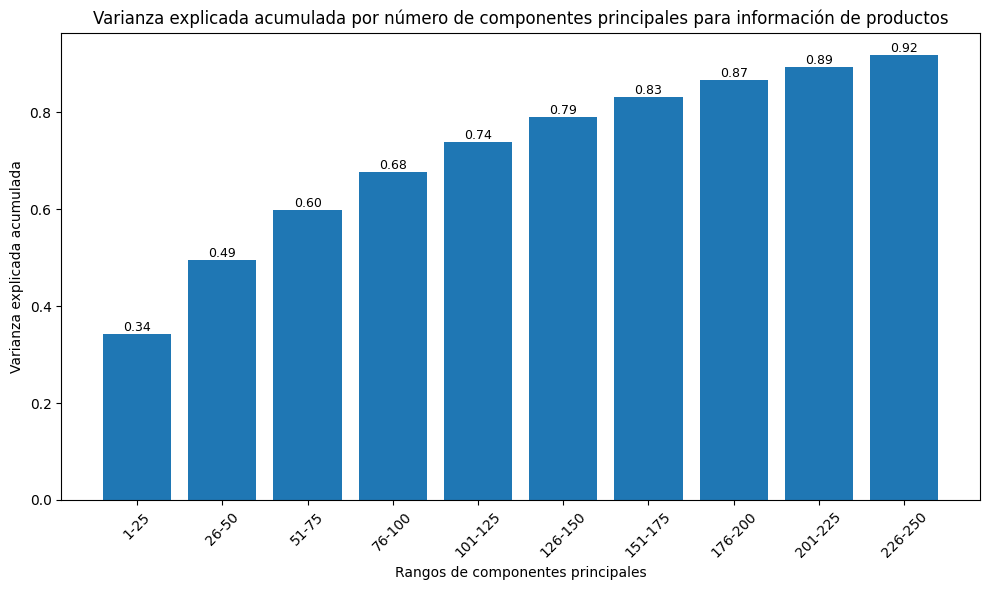

In [ ]:
pca_encoder_phrases.plot_explained_variance_cumsum_binned(
    title = "Varianza explicada acumulada por número de componentes principales para información de productos"
)

In [ ]:
f"Varianza total explicada: {sum(pca_encoder_phrases.model.explainedVariance)}"

'Varianza total explicada: 0.9175949082743136'

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    df_vectorized_pca_phrases = pca_encoder_phrases.transform(df_vectorized_phrases)
    (
        df_vectorized_pca_phrases.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_vectorized_pca_phrases', catalog = GOLD_SCHEMA))
    )

df_vectorized_pca_phrases = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca_phrases', catalog = GOLD_SCHEMA
))

Indexar registros de codificación de oraciones

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    df_vectorized_pca_phrases_with_index = (
        df_vectorized_pca_phrases
            .withColumn("index", F.monotonically_increasing_id())
            .write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_vectorized_pca_phrases_with_index', catalog = GOLD_SCHEMA))
    )

df_vectorized_pca_phrases_with_index = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca_phrases_with_index', catalog = GOLD_SCHEMA
))

### Reducción de componentes información de productos

In [53]:
from src.gold.training.pca import PCAEncoder

In [54]:
df_vectorized = meta_items_embeddings_equi.withColumn("features", array_to_vector("sum_embedding"))

In [55]:
pca_encoder = PCAEncoder(
    id_cols=["parent_asin"],
    input_col="features",
    output_col="pca_features",
    k=150
)

In [56]:
if REGENERATE_INTERMEDIATE_TABLES:
    pca_encoder.fit(df_vectorized)
    pca_encoder.save(spark_utils.path('pca_encoder', catalog = GOLD_SCHEMA))

pca_encoder = pca_encoder.load(spark_utils.path('pca_encoder', catalog = GOLD_SCHEMA))

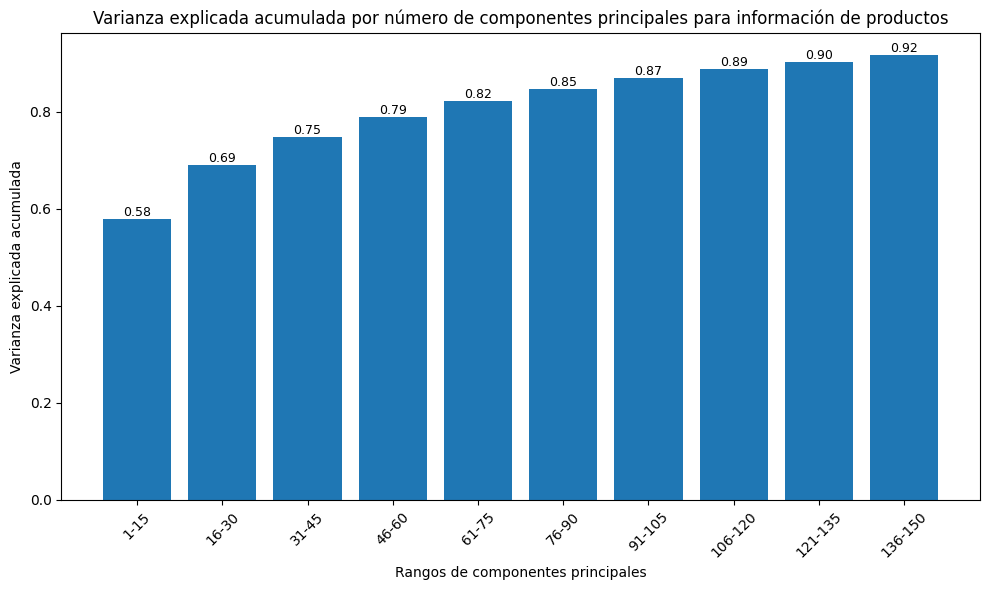

In [57]:
pca_encoder.plot_explained_variance_cumsum_binned(
    title = "Varianza explicada acumulada por número de componentes principales para información de productos"
)

In [58]:
f"Varianza total explicada: {sum(pca_encoder.model.explainedVariance)}"

'Varianza total explicada: 0.9166486477081565'

In [59]:
if REGENERATE_INTERMEDIATE_TABLES:
    df_vectorized_pca = pca_encoder.transform(df_vectorized)
    (
        df_vectorized_pca.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_vectorized_pca', catalog = GOLD_SCHEMA))
    )

df_vectorized_pca = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca', catalog = GOLD_SCHEMA
))

In [60]:
df_vectorized_pca_balanced = (
    df_vectorized_pca.alias('A')
        .join(
            df_items_sample_balanced.alias('B'),
            on='parent_asin',
            how='inner'
        )
        .select('A.*')
)

In [62]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        df_vectorized_pca_balanced.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_vectorized_pca_balanced', catalog = GOLD_SCHEMA))
    )

df_vectorized_pca_balanced = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca_balanced', catalog = GOLD_SCHEMA
))

### Reducción de componentes información de productos (miniLLM)

In [ ]:
from src.gold.training.pca import PCAEncoder

In [ ]:
df_vectorized_equi_minillm = meta_items_embeddings_equi_minillm.withColumn("features", array_to_vector("sum_embedding"))

In [ ]:
pca_encoder_minillm = PCAEncoder(
    id_cols=["parent_asin"],
    input_col="features",
    output_col="pca_features",
    k=125
)

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    pca_encoder_minillm.fit(df_vectorized_equi_minillm)
    pca_encoder_minillm.save(spark_utils.path('pca_encoder_minillm', catalog = GOLD_SCHEMA))

pca_encoder_minillm = pca_encoder_minillm.load(spark_utils.path('pca_encoder_minillm', catalog = GOLD_SCHEMA))

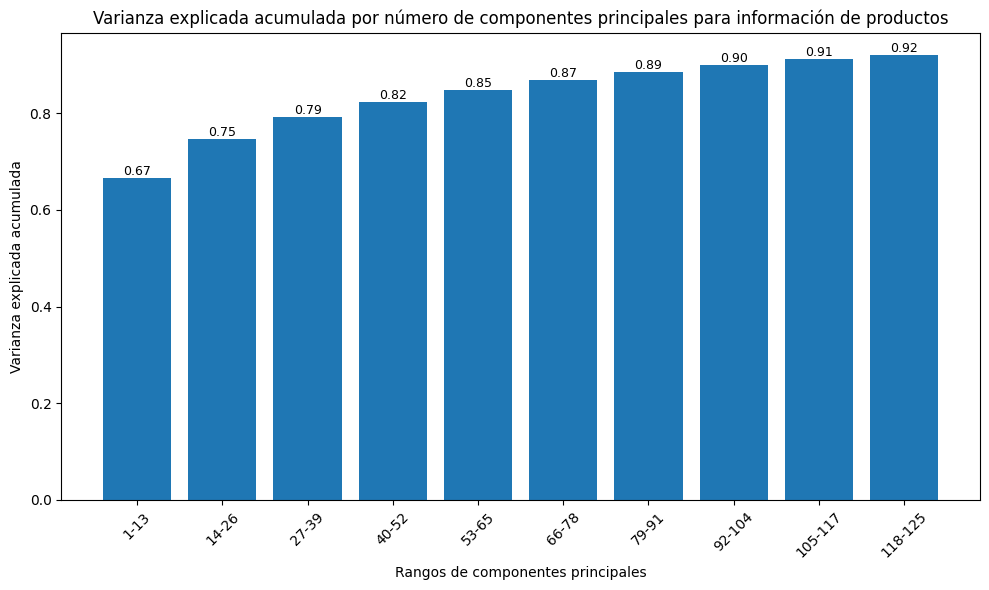

In [ ]:
pca_encoder_minillm.plot_explained_variance_cumsum_binned(
    title = "Varianza explicada acumulada por número de componentes principales para información de productos"
)

In [ ]:
f"Varianza total explicada: {sum(pca_encoder_minillm.model.explainedVariance)}"

'Varianza total explicada: 0.9205651366741103'

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    df_vectorized_pca_minillm = pca_encoder_minillm.transform(df_vectorized_equi_minillm)
    (
        df_vectorized_pca_minillm.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_vectorized_pca_minillm', catalog = GOLD_SCHEMA))
    )

df_vectorized_pca_minillm = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca_minillm', catalog = GOLD_SCHEMA
))

### Reducción de componentes información de reseñas

In [29]:
from src.gold.training.pca import PCAEncoder

In [ ]:
df_reviews_vectorized = reviews_embeddings_equi.withColumn("features", array_to_vector("text_embeddings"))

In [ ]:
reviews_pca_encoder = PCAEncoder(
    id_cols=["review_id"],
    input_col="features",
    output_col="pca_features",
    k=250
)

In [ ]:
if True:
    reviews_pca_encoder.fit(df_reviews_vectorized)
    reviews_pca_encoder.save(spark_utils.path('reviews_pca_encoder', catalog = GOLD_SCHEMA))

reviews_pca_encoder = reviews_pca_encoder.load(spark_utils.path('reviews_pca_encoder', catalog = GOLD_SCHEMA))

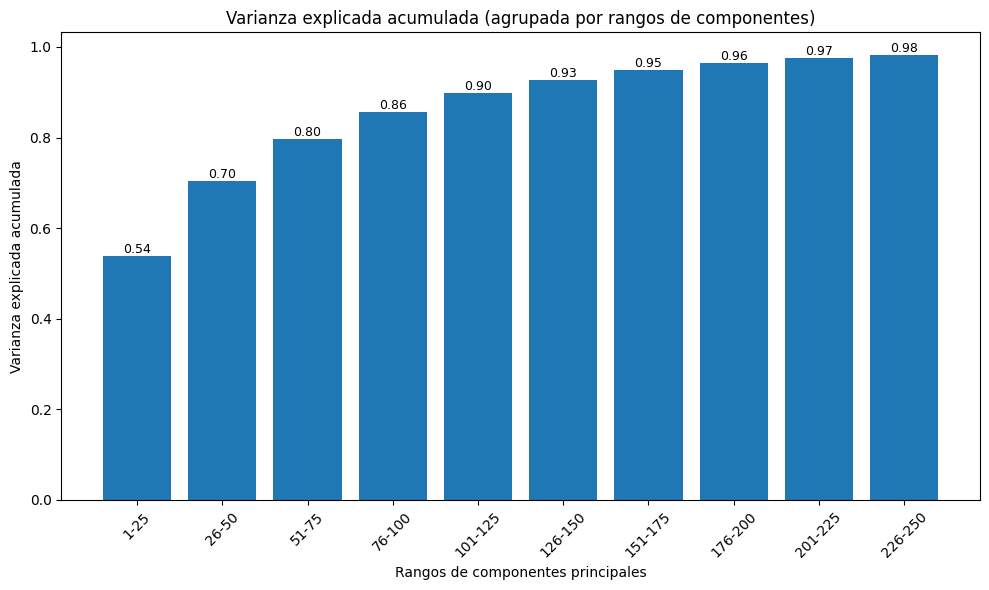

In [ ]:
reviews_pca_encoder.plot_explained_variance_cumsum_binned()

In [ ]:
sum(reviews_pca_encoder.model.explainedVariance)

0.9830682533312591

In [ ]:
if True:
    df_reviews_vectorized_pca = reviews_pca_encoder.transform(df_reviews_vectorized)
    (
        df_reviews_vectorized_pca.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_reviews_vectorized_pca', catalog = GOLD_SCHEMA))
    )

df_reviews_vectorized_pca = spark.read.format('delta').load(spark_utils.path(
    'df_reviews_vectorized_pca', catalog = GOLD_SCHEMA
))

### Reducción componentes información de reseñas agrupada

In [25]:
from src.gold.training.pca import PCAEncoder

In [41]:
reviews_embeddings_sample_balanced.schema.fields

[StructField('review_id', IntegerType(), True),
 StructField('text_embeddings', VectorUDT(), True)]

In [26]:
df_reviews_vectorized_sample_balanced = reviews_embeddings_sample_balanced.withColumn("features", F.col("text_embeddings"))

In [27]:
reviews_pca_encoder_grouped = PCAEncoder(
    id_cols=["review_id"],
    input_col="features",
    output_col="pca_features",
    k=250
)

In [28]:
if REGENERATE_INTERMEDIATE_TABLES:
    reviews_pca_encoder_grouped.fit(df_reviews_vectorized_sample_balanced)
    reviews_pca_encoder_grouped.save(spark_utils.path('reviews_pca_encoder_grouped', catalog = GOLD_SCHEMA))

reviews_pca_encoder_grouped = reviews_pca_encoder_grouped.load(spark_utils.path('reviews_pca_encoder_grouped', catalog = GOLD_SCHEMA))

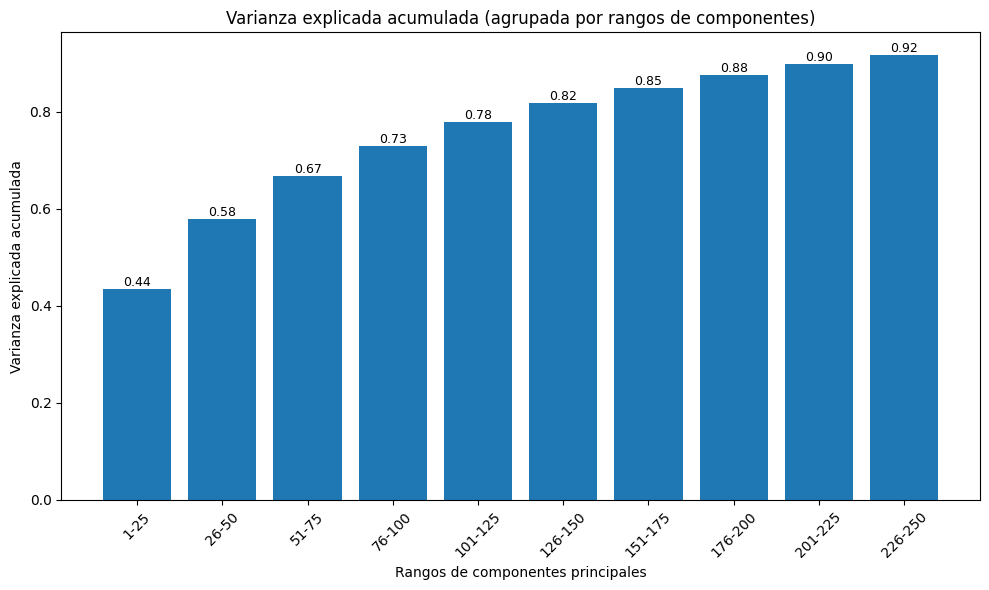

In [29]:
reviews_pca_encoder_grouped.plot_explained_variance_cumsum_binned()

In [30]:
sum(reviews_pca_encoder_grouped.model.explainedVariance)

0.9179023480096271

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    df_reviews_vectorized_pca_grouped = reviews_pca_encoder_grouped.transform(df_reviews_vectorized_sample_balanced)
    (
        df_reviews_vectorized_pca_grouped.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_reviews_vectorized_pca_grouped', catalog = GOLD_SCHEMA))
    )

df_reviews_vectorized_pca_grouped = spark.read.format('delta').load(spark_utils.path(
    'df_reviews_vectorized_pca_grouped', catalog = GOLD_SCHEMA
))

### Reducción de componentes información de reseñas (por oración)

In [25]:
from src.gold.training.pca import PCAEncoder

In [ ]:
df_reviews_vectorized_balanced_sample_sentence = reviews_indexed_sentences_items_sample_balanced_embeddings.select(
    F.col('record_id'), array_to_vector(F.col('text_embeddings')).alias("features")
)

In [ ]:
reviews_pca_encoder_sentence_balanced = PCAEncoder(
    id_cols=["record_id"],
    input_col="features",
    output_col="pca_features",
    k=250
)

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    reviews_pca_encoder_sentence_balanced.fit(df_reviews_vectorized_balanced_sample_sentence)
    reviews_pca_encoder_sentence_balanced.save(spark_utils.path('reviews_pca_encoder_sentence_balanced', catalog = GOLD_SCHEMA))

reviews_pca_encoder_sentence_balanced = reviews_pca_encoder_sentence_balanced.load(spark_utils.path('reviews_pca_encoder_sentence_balanced', catalog = GOLD_SCHEMA))

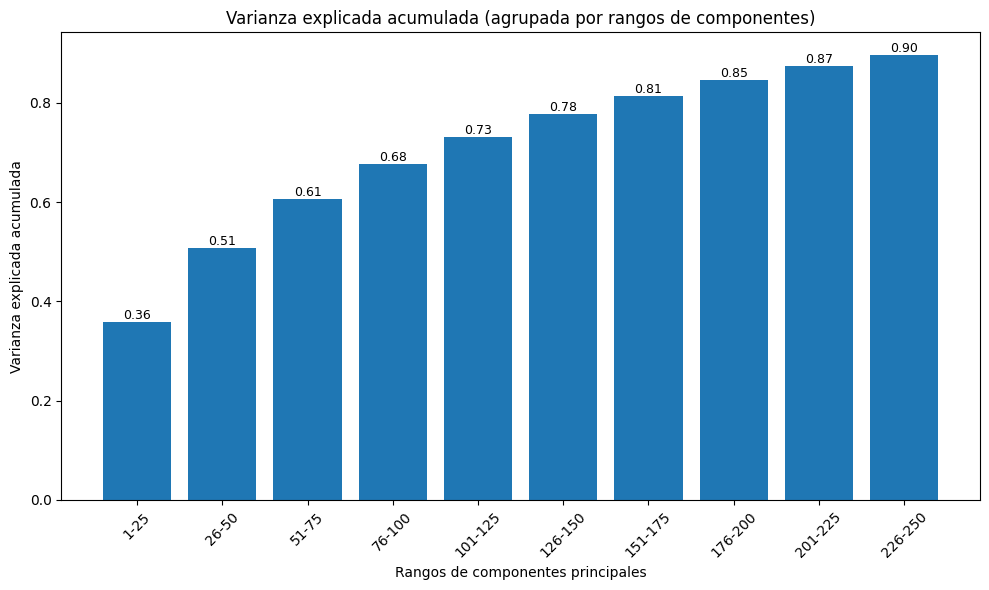

In [ ]:
reviews_pca_encoder_sentence_balanced.plot_explained_variance_cumsum_binned()

In [ ]:
sum(reviews_pca_encoder_sentence_balanced.model.explainedVariance)

0.8972284157379817

In [27]:
if REGENERATE_INTERMEDIATE_TABLES:
    df_reviews_vectorized_pca_sentence_balanced = reviews_pca_encoder_sentence_balanced.transform(df_reviews_vectorized_balanced_sample_sentence)
    (
        df_reviews_vectorized_pca_sentence_balanced
            .select(
                F.col('record_id'),
                F.col('pca_features')
            )
            .write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('df_reviews_vectorized_pca_sentence_balanced', catalog = GOLD_SCHEMA))
    )

df_reviews_vectorized_pca_sentence_balanced = spark.read.format('delta').load(spark_utils.path(
    'df_reviews_vectorized_pca_sentence_balanced', catalog = GOLD_SCHEMA
))

### Agrupación en función de reducción

In [51]:
reviews_embeddings_equi_sample_balanced_pca = (
    df_reviews_vectorized_pca_sentence_balanced.alias('A')
        .join(
            reviews_indexed_sentences.alias('B'),
            on = 'record_id',
            how = 'inner'
        ).withColumn(
            "weighted_embedding", F.col("pca_features")
        )
        .groupBy("review_id") 
        .agg(mean_summarizer.summary(F.col("weighted_embedding")).alias("text_embeddings"))
        .select("review_id", F.col("text_embeddings.mean").alias('pca_features'))
)

In [26]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        reviews_embeddings_equi_sample_balanced_pca.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'reviews_embeddings_equi_sample_balanced_pca', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
reviews_embeddings_equi_sample_balanced_pca = spark.read.format('delta').load(spark_utils.path(
    'reviews_embeddings_equi_sample_balanced_pca', catalog = GOLD_SCHEMA_ENCODING
))

### Reparticionar por review_id

In [27]:
reviews_embeddings_equi_sample_balanced_pca_repartitioned = (
    reviews_embeddings_equi_sample_balanced_pca
        .repartition(F.col('review_id'))
)

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        reviews_embeddings_equi_sample_balanced_pca_repartitioned.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path(
                'reviews_embeddings_equi_sample_balanced_pca_repartitioned', catalog=GOLD_SCHEMA_ENCODING
            ))
    )
reviews_embeddings_equi_sample_balanced_pca_repartitioned = spark.read.format('delta').load(spark_utils.path(
    'reviews_embeddings_equi_sample_balanced_pca_repartitioned', catalog = GOLD_SCHEMA_ENCODING
))